# Healthcare Predictive Analytics: Heart Disease Detection

This notebook predicts the risk of heart disease using patient medical records.

The project follows these steps:

1. Import libraries
2. Load the dataset
3. Understand the dataset
4. Clean the data
5. Create the target variable
6. Perform exploratory data analysis
7. Preprocess categorical and numerical features
8. Normalize numerical records
9. Train classification models
10. Evaluate model performance
11. Analyze feature importance
12. Highlight ethical data handling and patient privacy

In [1]:
# This block imports all required libraries for data handling, visualization, preprocessing, modeling, and evaluation.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

In [2]:
# This block loads the heart disease dataset from the uploaded CSV file.

df = pd.read_csv("heart_disease_uci (1).csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
# This block checks the number of rows and columns in the dataset.

df.shape

(920, 16)

In [4]:
# This block checks the column names, data types, and missing values.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [5]:
# This block checks the number of missing values in each column.

df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [6]:
# This block checks basic statistical details of numerical columns.

df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [7]:
# This block checks basic details of categorical columns.

df.describe(include="object")

,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


In [8]:
# This block checks whether duplicate records are present in the dataset.

df.duplicated().sum()

np.int64(0)

In [9]:
# This block removes duplicate records if any duplicates are found.

df = df.drop_duplicates()

df.shape

(920, 16)

## Target Variable

The original target column is `num`.

In this dataset:

- `num = 0` means no heart disease
- `num = 1, 2, 3, or 4` means heart disease is present

For a simple classification project, we convert it into a binary target:

- `0 = No Heart Disease`
- `1 = Heart Disease`

In [10]:
# This block creates a binary target column for heart disease detection.

df["heart_disease"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

df[["num", "heart_disease"]].head()

,num,heart_disease
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


In [11]:
# This block checks the distribution of the final target variable.

df["heart_disease"].value_counts()

,count
heart_disease,
1,509
0,411


In [12]:
# This block checks the target distribution in percentage form.

df["heart_disease"].value_counts(normalize=True) * 100

,proportion
heart_disease,
1,55.326087
0,44.673913


## Exploratory Data Analysis

EDA helps us understand patterns in the dataset before building the machine learning model.

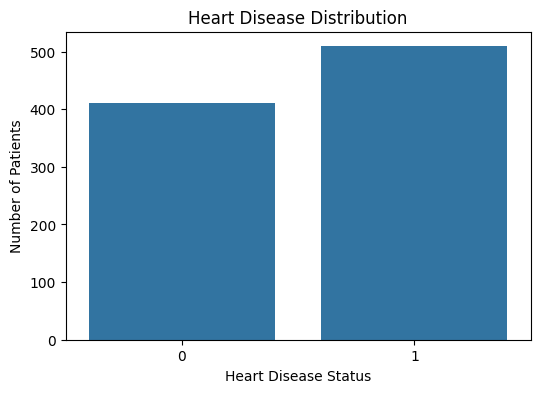

In [13]:
# This block visualizes the number of patients with and without heart disease.

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="heart_disease")
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")
plt.show()

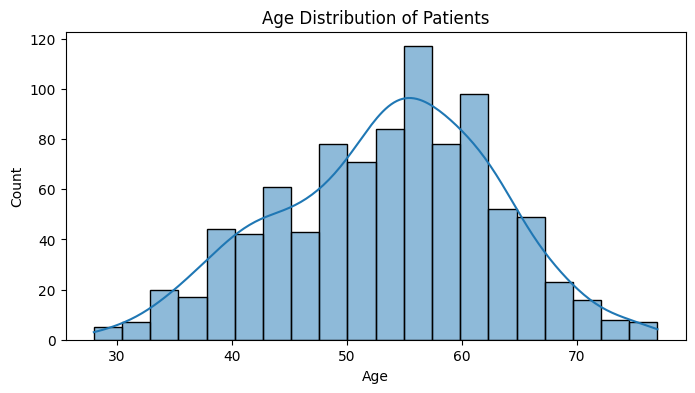

In [14]:
# This block visualizes age distribution of patients.

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="age", bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

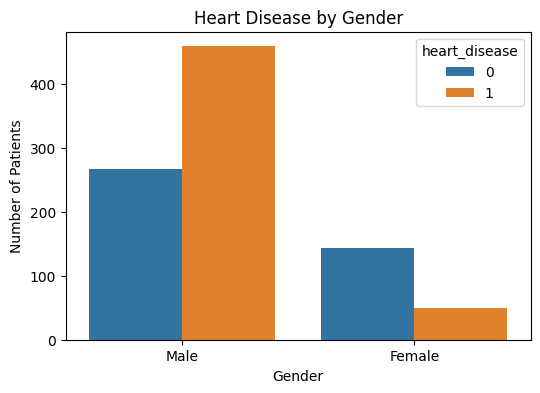

In [15]:
# This block compares heart disease status across gender.

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sex", hue="heart_disease")
plt.title("Heart Disease by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

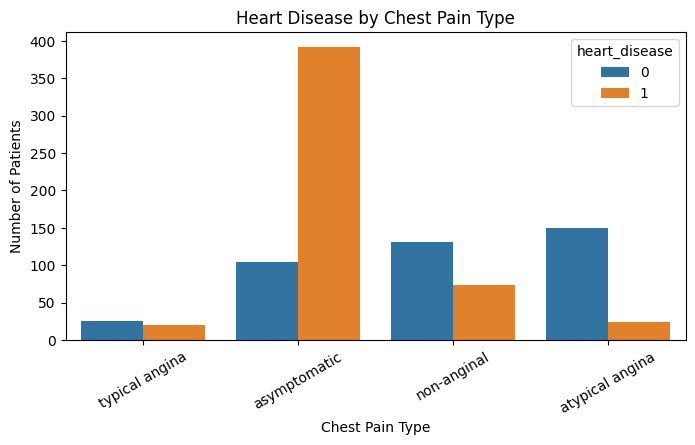

In [16]:
# This block compares chest pain type with heart disease status.

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="cp", hue="heart_disease")
plt.title("Heart Disease by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)
plt.show()

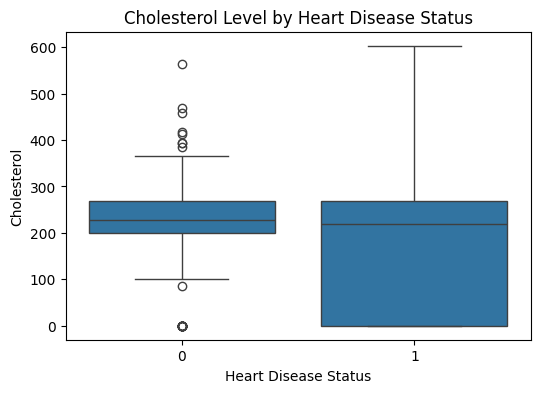

In [17]:
# This block compares average cholesterol level for patients with and without heart disease.

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="heart_disease", y="chol")
plt.title("Cholesterol Level by Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Cholesterol")
plt.show()

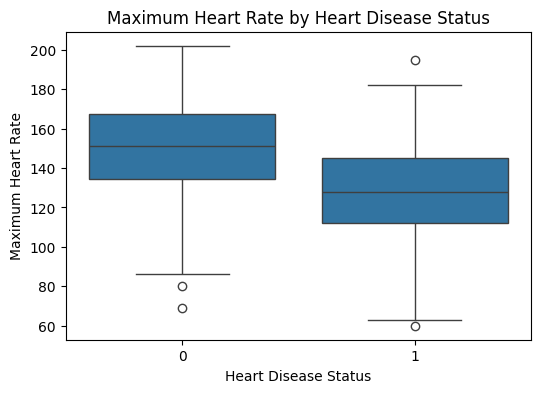

In [18]:
# This block compares maximum heart rate for patients with and without heart disease.

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="heart_disease", y="thalch")
plt.title("Maximum Heart Rate by Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Maximum Heart Rate")
plt.show()

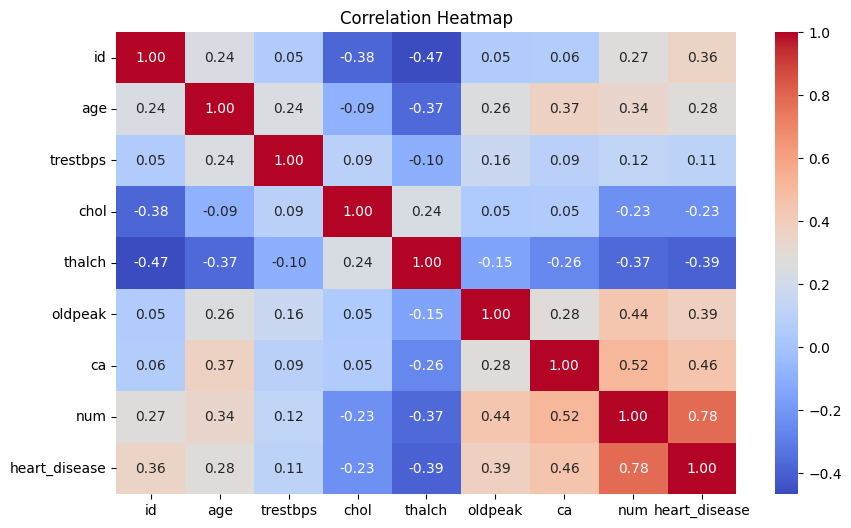

In [19]:
# This block shows correlation between numerical features.

numeric_columns_for_corr = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_columns_for_corr].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Feature Selection

The columns `id`, `dataset`, and `num` are removed.

Reason:

- `id` is only a unique identifier.
- `dataset` shows the source/location of records and is not a direct medical risk factor.
- `num` is the original target column, and we already created `heart_disease`.

In [20]:
# This block separates independent features and the target variable.

X = df.drop(columns=["id", "dataset", "num", "heart_disease"])
y = df["heart_disease"]

X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal


In [21]:
# This block identifies numerical and categorical columns separately.

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "bool"]).columns

numerical_features, categorical_features

(Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca'], dtype='object'),
 Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object'))

## Train-Test Split

The dataset is divided into training and testing data.

- Training data is used to train the model.
- Testing data is used to check model performance on unseen records.

In [22]:
# This block splits the dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((736, 13), (184, 13))

## Data Preprocessing and Normalization

Healthcare records often contain missing values and values with different scales.

For numerical columns:

- Missing values are filled using median.
- Values are normalized using StandardScaler.

For categorical columns:

- Missing values are filled using the most frequent value.
- Categories are converted into numerical form using OneHotEncoder.

In [23]:
# This block creates preprocessing steps for numerical and categorical columns.

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

## Model Training

We will train four simple classification models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine

These models are beginner-friendly and suitable for viva explanation.

In [24]:
# This block creates a dictionary of machine learning models.

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

In [25]:
# This block trains each model and stores evaluation results.

results = []

trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba)
    })

    trained_models[model_name] = pipeline

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.842391,0.841121,0.882353,0.861244,0.903515
1,Decision Tree,0.755435,0.771429,0.794118,0.782609,0.750717
2,Random Forest,0.847826,0.849057,0.882353,0.865385,0.919955
3,Support Vector Machine,0.842391,0.817391,0.921569,0.866359,0.916667


In [26]:
# This block finds the best model based on ROC-AUC score.

best_model_name = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_model_name

'Random Forest'

## Model Evaluation

The best model is evaluated using:

- Classification Report
- Confusion Matrix
- ROC Curve

In [27]:
# This block generates predictions using the best model.

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

classification_report(y_test, y_pred_best)

'              precision    recall  f1-score   support\n\n           0       0.85      0.80      0.82        82\n           1       0.85      0.88      0.87       102\n\n    accuracy                           0.85       184\n   macro avg       0.85      0.84      0.85       184\nweighted avg       0.85      0.85      0.85       184\n'

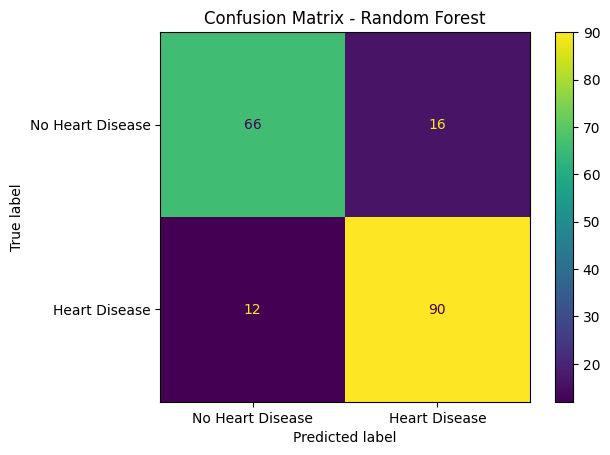

In [28]:
# This block displays the confusion matrix for the best model.

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Heart Disease", "Heart Disease"])
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

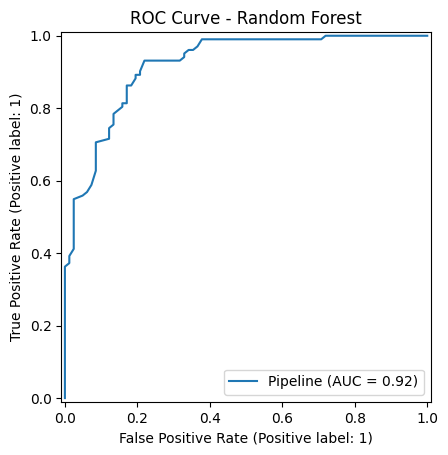

In [29]:
# This block displays the ROC curve for the best model.

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"ROC Curve - {best_model_name}")
plt.show()

## Feature Importance Analysis

Feature importance helps us understand which health indicators are most useful in predicting heart disease risk.

For this project, Random Forest feature importance is used because it is easy to explain and works well with both numerical and encoded categorical features.

In [30]:
# This block trains a Random Forest model for feature importance analysis.

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object'))])),
                ('model', RandomForestClassifier(random_state=42))])

In [31]:
# This block extracts feature names after preprocessing.

encoded_categorical_features = rf_pipeline.named_steps["preprocessor"]     .named_transformers_["cat"]     .named_steps["encoder"]     .get_feature_names_out(categorical_features)

all_feature_names = list(numerical_features) + list(encoded_categorical_features)

all_feature_names[:10]

['age',
 'trestbps',
 'chol',
 'thalch',
 'oldpeak',
 'ca',
 'sex_Female',
 'sex_Male',
 'cp_asymptomatic',
 'cp_atypical angina']

In [32]:
# This block creates a feature importance table.

feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_pipeline.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
2,chol,0.135639
3,thalch,0.112963
0,age,0.110822
4,oldpeak,0.089136
8,cp_asymptomatic,0.088891
1,trestbps,0.071717
18,exang_True,0.069506
9,cp_atypical angina,0.043076
17,exang_False,0.036572
23,thal_normal,0.027147


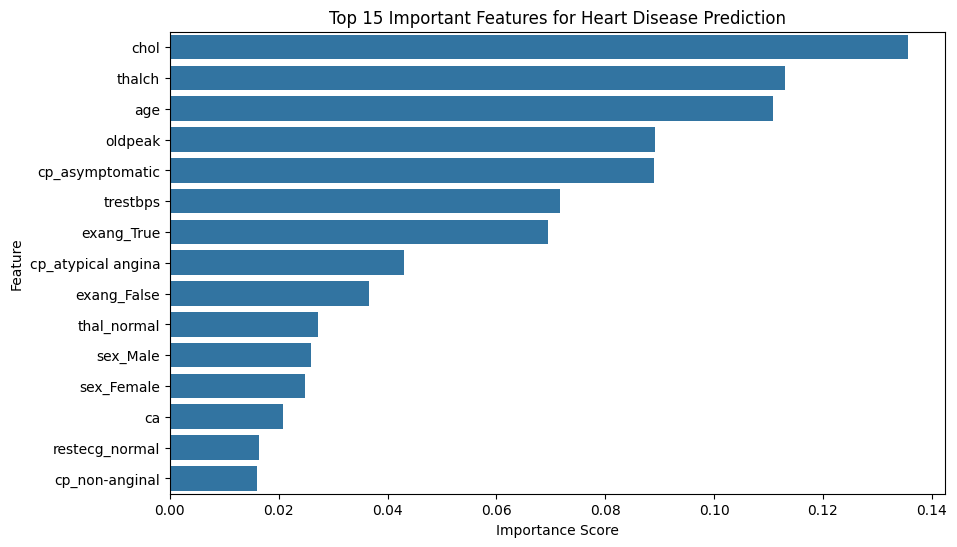

In [33]:
# This block visualizes the top 15 important features.

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 15 Important Features for Heart Disease Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

## Single Patient Prediction Example

This example shows how the model can predict risk for a new patient record.

The values used here are only for demonstration.

In [34]:
# This block creates a sample patient record for prediction.

sample_patient = pd.DataFrame({
    "age": [55],
    "sex": ["Male"],
    "cp": ["asymptomatic"],
    "trestbps": [140],
    "chol": [240],
    "fbs": [False],
    "restecg": ["normal"],
    "thalch": [150],
    "exang": [True],
    "oldpeak": [1.5],
    "slope": ["flat"],
    "ca": [0],
    "thal": ["normal"]
})

sample_patient

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,55,Male,asymptomatic,140,240,False,normal,150,True,1.5,flat,0,normal


In [35]:
# This block predicts heart disease risk for the sample patient.

sample_prediction = best_model.predict(sample_patient)
sample_probability = best_model.predict_proba(sample_patient)[:, 1]

sample_prediction, sample_probability

(array([1]), array([0.86]))

## Business and Healthcare Insights

Based on this project, the healthcare organization can:

1. Identify patients with higher heart disease risk.
2. Support early screening and preventive care.
3. Understand important risk indicators such as age, chest pain type, cholesterol, heart rate, and exercise-induced symptoms.
4. Help doctors prioritize high-risk patients for further diagnosis.
5. Reduce treatment cost by encouraging early intervention.

The model should support medical decision-making, not replace doctors.

## Ethical Data Handling and Patient Privacy

Healthcare data is highly sensitive. While working with this type of dataset, the following points are important:

1. Patient identity should be protected.
2. Personal information should not be shared publicly.
3. The model should not be used as the only basis for medical decisions.
4. Bias should be checked because healthcare datasets may not represent all groups equally.
5. Model predictions should be explained clearly to doctors and patients.
6. Data should be stored securely and accessed only by authorized people.

## Final Conclusion

This project successfully built a heart disease prediction system using machine learning.

The project included:

- Data understanding
- Data cleaning
- Missing value treatment
- Normalization
- Categorical encoding
- Classification modeling
- Model evaluation
- Feature importance analysis
- Ethical healthcare data handling

This makes the project suitable for healthcare predictive analytics and viva explanation.